In [12]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc

# Set pandas display options
pd.set_option('display.max_columns', 100)

# Load data
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz',
                        sep=',', header=0)

ROC_esmcba = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/binding_affinity/ROC_Curve_peptides.csv')

# Clean and merge data
IEDB_full['MHC Restriction - Name'] = IEDB_full['MHC Restriction - Name'].str.replace('HLA','')
ROC_esmcba = pd.merge(left=ROC_esmcba, right=IEDB_full[['Epitope - Name', 'Assay - Qualitative Measurement','MHC Restriction - Name']], 
                      left_on=['sequence','level_0'], 
                      right_on=['Epitope - Name','MHC Restriction - Name'])

df = ROC_esmcba


/tmp/ipykernel_3339739/3247377596.py:12: DtypeWarning: Columns (6,12,13,14,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,65,66,67,68,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz',


In [22]:
ROC_esmcba['sequence'].value_counts()

sequence
RTQNVLGEK     56
STDHIPILY     42
SSEQTFMYY     40
TPQSNRPVM     32
APKRPPSAF     30
              ..
YQGMLPVCPL     1
LLSINSSFY      1
CANGWIQYDK     1
TIREFPRKDK     1
ITLKIIETY      1
Name: count, Length: 10747, dtype: int64

In [2]:
# Load additional model prediction datasets
roc_apollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_HLApollo_final.csv')
roc_nugg = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_mhcnuggets.csv')
ROC_curve_mixmhcpred = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_mixmhcpred.csv')
ROC_athena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_Peptides_HLAthena_combined.csv')

# Select relevant columns for each dataset
ROC_athena = ROC_athena[['pep', 'HLA', 'MSi']]
ROC_curve_mixmhcpred = ROC_curve_mixmhcpred[['sequence', 'Allele', 'MixMHCpred_%Rank']]

# Clean allele names for MHCnuggets
roc_nugg['allele'] = roc_nugg['allele'].str.replace('HLA-', '').str.replace('*', '').str.replace(':', '')
roc_nugg = roc_nugg[['peptide', 'allele', 'ic50']]

# Clean allele names for HLApollo
roc_apollo['allele'] = roc_apollo['allele'].str.replace('*', '').str.replace(':', '')
roc_apollo = roc_apollo[['allele', 'peptide', 'mhc_pred_0']]

In [3]:
# Prepare datasets for merging by standardizing column names
roc_apollo_clean = roc_apollo.rename(columns={
    'allele': 'level_0', 
    'peptide': 'sequence', 
    'mhc_pred_0': 'apollo_pred'
})

roc_nugg_clean = roc_nugg.rename(columns={
    'allele': 'level_0', 
    'peptide': 'sequence', 
    'ic50': 'nugg_pred'
})

ROC_curve_mixmhcpred_clean = ROC_curve_mixmhcpred.rename(columns={
    'Allele': 'level_0', 
    'MixMHCpred_%Rank': 'mixmhc_pred'
})

ROC_athena_clean = ROC_athena.rename(columns={
    'HLA': 'level_0', 
    'pep': 'sequence', 
    'MSi': 'athena_pred'
})

# Start with the main ESMCBA dataframe (assuming it's already merged with IEDB_full)
# df = ROC_esmcba (already contains ESMCBA predictions + IEDB labels)

# Merge all additional model predictions
df = pd.merge(df, roc_apollo_clean, on=['sequence', 'level_0'], how='left')
df = pd.merge(df, roc_nugg_clean, on=['sequence', 'level_0'], how='left')
df = pd.merge(df, ROC_curve_mixmhcpred_clean, on=['sequence', 'level_0'], how='left')
df = pd.merge(df, ROC_athena_clean, on=['sequence', 'level_0'], how='left')

# Check the final dataframe structure
print("Final dataframe columns:", df.columns.tolist())
print("Final dataframe shape:", df.shape)
print("Available prediction columns:", [col for col in df.columns if 'pred' in col or col in ['mhc_log', 'netmhc_log', 'prediction']])

Final dataframe columns: ['Unnamed: 0', 'level_0', 'level_1', 'sequence', 'prediction', 'UMAP_1', 'UMAP_2', 'allele', 'peptide', 'mhcflurry_affinity', 'mhcflurry_affinity_percentile', 'mhcflurry_processing_score', 'mhcflurry_presentation_score', 'mhcflurry_presentation_percentile', 'mhc_log', 'Peptide', 'netmhc_log', 'Epitope - Name', 'Assay - Qualitative Measurement', 'MHC Restriction - Name', 'apollo_pred', 'nugg_pred', 'mixmhc_pred', 'athena_pred']
Final dataframe shape: (22673, 24)
Available prediction columns: ['prediction', 'mhc_log', 'netmhc_log', 'apollo_pred', 'nugg_pred', 'mixmhc_pred', 'athena_pred']


In [4]:
df = df.drop_duplicates(['sequence','level_0'])

In [5]:
df

,Unnamed: 0,level_0,level_1,sequence,prediction,UMAP_1,UMAP_2,allele,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile,mhc_log,Peptide,netmhc_log,Epitope - Name,Assay - Qualitative Measurement,MHC Restriction - Name,apollo_pred,nugg_pred,mixmhc_pred,athena_pred
0,0,A3101,0,LVMAFIAFLR,1.716352,9.400377,9.829111,A3101,LVMAFIAFLR,47.610620,0.179625,0.014859,0.651150,0.523071,1.677704,LVMAFIAFLR,0.0655,LVMAFIAFLR,Positive-Intermediate,A3101,-40.950534,12742.66,0.606082,0.891321
1,1,A3101,1,RVQFIPGQR,1.333629,10.547241,10.252823,A3101,RVQFIPGQR,27.052885,0.026500,0.605975,0.963195,0.028207,1.432214,RVQFIPGQR,0.0791,RVQFIPGQR,Positive-High,A3101,8.867549,7458.21,0.028972,0.943484
2,2,A3101,2,TTIEDILPK,3.270586,4.388390,7.108198,A3101,TTIEDILPK,349.300240,0.994250,0.783229,0.803277,0.272717,2.543199,TTIEDILPK,7.2197,TTIEDILPK,Positive-Low,A3101,-30.017227,25202.64,1.474519,0.487147
4,3,A3101,3,EWIEFTNFK,3.445037,5.129343,7.055591,A3101,EWIEFTNFK,353.830628,0.998625,0.105149,0.268008,1.490353,2.548795,EWIEFTNFK,4.5710,EWIEFTNFK,Negative,A3101,-41.677007,31742.59,18.358012,0.054846
5,4,A3101,4,GLYEAIEEC,3.862112,3.195962,4.512225,A3101,GLYEAIEEC,27655.407983,19.478750,0.014118,0.003831,99.286603,4.441780,GLYEAIEEC,35.8116,GLYEAIEEC,Negative,A3101,-44.117674,128.81,9.430903,0.027048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22668,18264,A3201,840,RSLIGNEEF,1.874448,7.283777,7.745641,A3201,RSLIGNEEF,87.235400,0.317875,0.449828,0.828476,0.233451,1.940693,RSLIGNEEF,0.7368,RSLIGNEEF,Positive-Low,A3201,-27.055730,22604.03,0.292537,0.537369
22669,18265,A3201,841,ITLVVISVI,2.314525,8.419599,2.160718,A3201,ITLVVISVI,1595.470326,2.169375,0.030071,0.061034,4.329592,3.202889,ITLVVISVI,0.8231,ITLVVISVI,Negative,A3201,-40.194771,1651.70,0.417123,0.233911
22670,18266,A3201,842,GVSGGAWVDL,2.117750,7.954819,7.638033,A3201,GVSGGAWVDL,12688.262890,7.502750,0.010191,0.008020,27.617391,4.103402,GVSGGAWVDL,11.4780,GVSGGAWVDL,Negative,A3201,-39.281236,15443.67,15.803533,0.056925
22671,18267,A3201,843,ELGNILSVY,2.303372,8.354658,6.726958,A3201,ELGNILSVY,3842.852076,3.356250,0.315800,0.070682,3.807446,3.584654,ELGNILSVY,14.3288,ELGNILSVY,Negative,A3201,-26.629568,20731.87,1.925882,0.064415


In [6]:
df['level_0'].nunique()

21

In [7]:

# Define comparison pairs
pairs_to_plot = [
    ('Negative', 'Positive'),
    ('Negative', 'Positive-Low'),
    ('Negative', 'Positive-Intermediate'),
    ('Negative', 'Positive-High'),
    ('Positive-Low', 'Positive-High'),
    ('Positive-Intermediate', 'Positive-High'),
    ('Positive-Low', 'Positive-Intermediate'),
]

# Store AUCs per allele and per comparison
roc_results = {pair: {'ESMCBA': [], 'MHCflurry': [], 'NetMHCpan': [], 'HLApollo': [], 'MHCnuggets': [], 'MixMHCpred': [], 'HLAthena': []} for pair in pairs_to_plot}

for hla in df['level_0'].unique():
    df_sub = df[df['level_0'] == hla]
    for cat1, cat2 in pairs_to_plot:
        subset = df_sub[df_sub['Assay - Qualitative Measurement'].isin([cat1, cat2])].copy()
        if subset.empty or subset['Assay - Qualitative Measurement'].nunique() < 2:
            continue
        subset['label'] = (subset['Assay - Qualitative Measurement'] == cat1).astype(int)
        
        # Compute ROC for each model
        model_columns = [
            ('prediction', 'ESMCBA'),
            ('mhc_log', 'MHCflurry'),
            ('netmhc_log', 'NetMHCpan'),
            ('apollo_pred', 'HLApollo'),
            ('nugg_pred', 'MHCnuggets'),
            ('mixmhc_pred', 'MixMHCpred'),
            ('athena_pred', 'HLAthena')
        ]
        
        for col, label in model_columns:
            if col not in subset or subset[col].isnull().all():
                continue
            try:
                # Flip signs for HLApollo and HLAthena (they use opposite scoring)
                if label in ['HLApollo', 'HLAthena']:
                    prediction_values = -subset[col]
                else:
                    prediction_values = subset[col]
                
                fpr, tpr, _ = roc_curve(subset['label'], prediction_values)
                score = auc(fpr, tpr)
                roc_results[(cat1, cat2)][label].append(score)
            except Exception:
                continue

# Prepare long-format DataFrame for plotting
records = []
for (cat1, cat2), model_scores in roc_results.items():
    for model, scores in model_scores.items():
        for auc_score in scores:
            records.append({
                'Comparison': f'{cat1} vs {cat2}',
                'Model': model,
                'AUC': auc_score
            })

auc_df = pd.DataFrame(records)

In [8]:

pairs_to_plot = [
    ('Negative', 'Positive'),
    ('Negative', 'Positive-High'),
    ('Negative', 'Positive-Intermediate'),
    ('Negative', 'Positive-Low'),
    ('Positive-Intermediate', 'Positive-High'),
    ('Positive-Low', 'Positive-Intermediate')
]

# Define the exact model order from your plot
model_order = ['ESMCBA', 'HLApollo', 'HLAthena', 'MHCflurry', 'MHCnuggets', 'MixMHCpred', 'NetMHCpan']

# Prepare long-format DataFrame for plotting
records = []
for (cat1, cat2), model_scores in roc_results.items():
    for model, scores in model_scores.items():
        for auc_score in scores:
            records.append({
                'Comparison': f'{cat1} vs\n{cat2}',
                'Model': model,
                'AUC': auc_score
            })

auc_df = pd.DataFrame(records)

# Filter to only include the 6 comparisons we want
auc_df = auc_df[auc_df['Comparison'].isin([f'{cat1} vs\n{cat2}' for cat1, cat2 in pairs_to_plot])]

/tmp/ipykernel_3339739/2171192408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 38.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  w

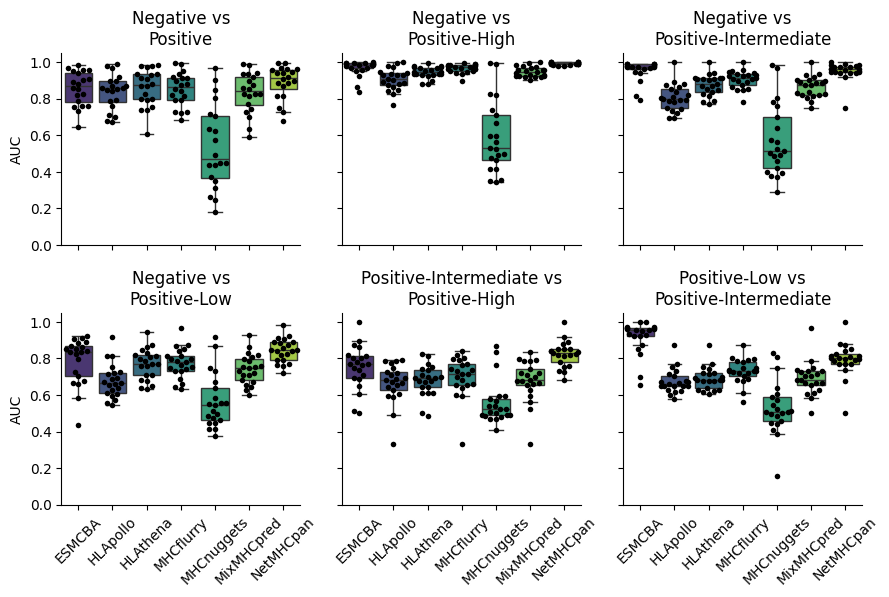

In [9]:

# Create the plot with 2 rows × 3 columns layout (matching your image)
g = sns.catplot(
    data=auc_df,
    x='Model', y='AUC',
    col='Comparison',
    kind='box',
    height=3, aspect=1,  # Adjust aspect ratio to match your plot
    palette='viridis',
    showfliers=False,
    col_wrap=3,  # 3 columns per row
    order=model_order,  # Use the exact model order
    col_order=[f'{cat1} vs\n{cat2}' for cat1, cat2 in pairs_to_plot]  # Exact comparison order
)

# Overlay swarmplot per panel with smaller points
for ax, (comp, sub_df) in zip(g.axes.flat, auc_df.groupby('Comparison')):
    sns.swarmplot(
        data=sub_df,
        x='Model', y='AUC',
        ax=ax,
        color='black',
        size=4,  # Smaller points to match your plot
        order=model_order  # Maintain model order
    )
    
    # Rotate x-axis labels to match your plot
    ax.tick_params(axis='x', rotation=45)

# Set titles and labels
g.set_titles("{col_name}", size=12)
g.set_axis_labels("", "AUC")
g.set(ylim=(0.0, 1.05))

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Add space for rotated labels

plt.savefig("../../figures_manuscript/5a_ROC_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
auc_df

,Comparison,Model,AUC
0,Negative vs\nPositive,ESMCBA,0.760762
1,Negative vs\nPositive,ESMCBA,0.646492
2,Negative vs\nPositive,ESMCBA,0.733150
3,Negative vs\nPositive,ESMCBA,0.982727
4,Negative vs\nPositive,ESMCBA,0.823529
...,...,...,...
1017,Positive-Low vs\nPositive-Intermediate,HLAthena,0.680308
1018,Positive-Low vs\nPositive-Intermediate,HLAthena,0.682183
1019,Positive-Low vs\nPositive-Intermediate,HLAthena,0.767079
1020,Positive-Low vs\nPositive-Intermediate,HLAthena,0.629085
